***

## Implement co-teaching

In this notebook, we will do the following:
* Load the Assignment data
* Add symmetric noise over it
* Create the model that has been mentioned in the paper
* Train it using co-teaching
* Get the loss values

***

In [1]:
pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 404.7/404.7 kB 22.1 MB/s eta 0:00:00


In [2]:
import torch
import numpy as np

# from google.colab import drive
import seaborn as sns

from torch.utils.data import DataLoader, Dataset
import torch.nn.functional as F
from PIL import Image
import torchvision.transforms as transforms
from torchvision import datasets, models
import optuna

%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import torchvision


In [3]:
sns.set_style(style="darkgrid")

In [5]:
from google.colab import drive
drive.mount('/content/drive')

import shutil
import os

# Your original drive path
drive_path = "/content/drive/MyDrive/project_CNN_noisy_label/Dataset 1"
# # New local path
# local_path = "/content/local_dataset"

# # Copy the training data locally
# shutil.copytree(f"{drive_path}/train", f"{local_path}/train")

# # Update your path variables
# image_dir_train = f"{local_path}/train"

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, datasets
from torchvision.datasets import ImageFolder
import cv2
import matplotlib.pyplot as plt
import os
import shutil # New Import for file operations
from google.colab import drive

drive.mount('/content/drive')

print("CUDA available:", torch.cuda.is_available())

# #############################################
# #            Data Copy (The Fix for Slow I/O)
# #############################################

# # Define original paths on Google Drive
base_dir_drive = "/content/drive/MyDrive/project_CNN_noisy_label/Dataset 1"
# image_dir_train_drive = f"{base_dir_drive}/train"
image_dir_validation_drive = f"{base_dir_drive}/Dataset1"

# # Define new local paths for fast I/O
local_base_dir = "/content/local_dataset"
image_dir_train = f"{local_base_dir}/train"
image_dir_validation = f"{local_base_dir}/validation" # Renaming to 'validation' for clarity

# # Create the local directories
# os.makedirs(image_dir_train, exist_ok=True)
# os.makedirs(image_dir_validation, exist_ok=True)

# print("\n[INFO] Starting data copy from Google Drive to local storage...")
try:
#     # Copy the training data
#     shutil.copytree(image_dir_train_drive, image_dir_train, dirs_exist_ok=True)
#     print(f"[INFO] Copied training data to {image_dir_train}")

#     # Copy the validation data (Note: assuming 'Dataset1' is the validation folder name)
    shutil.copytree(image_dir_validation_drive, image_dir_validation, dirs_exist_ok=True)
    print(f"[INFO] Copied validation data to {image_dir_validation}")

except Exception as e:
    print(f"[ERROR] Failed to copy data. Ensure the paths are correct: {e}")

# #############################################
# #            Visualize Images (Using NEW local path)
# #############################################

# Now using the local path: image_dir_train
class_names = [i for i in os.listdir(image_dir_train)
               if os.path.isdir(os.path.join(image_dir_train, i))]
print("\nClasses:", class_names)

# Visualization loop (omitted for brevity, keep your original visualization code here)

#############################################
#            Transforms
#############################################

train_transforms = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomResizedCrop(128),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

valid_transform = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.CenterCrop(128),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

#############################################
#   Symmetric Label Noise (Co-Teaching)
#############################################

# (Keep your existing `apply_symmetric_noise` function definition here)
def apply_symmetric_noise(dataset, noise_rate):

    """

    Adds symmetric label noise:

    - Select noise_rate * N samples

    - Flip label to any other class RANDOMLY and uniformly

    """

    targets = np.array(dataset.targets)

    noisy_targets = targets.copy()



    num_classes = len(dataset.classes)

    n_samples = len(targets)

    n_noisy = int(n_samples * noise_rate)



    noisy_indices = np.random.choice(n_samples, n_noisy, replace=False)



    for idx in noisy_indices:

        current = targets[idx]



        # choose label uniformly from all other labels

        new_label = np.random.choice([c for c in range(num_classes) if c != current])

        noisy_targets[idx] = new_label



    dataset.targets = noisy_targets.tolist()



    print(f"[INFO] Applied symmetric noise: {noise_rate}")

    print(f"[INFO] Noisy samples: {n_noisy} / {n_samples}")



    return dataset

#############################################
#            Load Dataset (Using NEW local path)
#############################################

NOISE_RATE = 0.6
print(NOISE_RATE)

image_dataset = ImageFolder(image_dir_train, transform=train_transforms)
image_dataset_validation = ImageFolder(image_dir_validation, transform=valid_transform)

# Apply noise here
image_dataset = apply_symmetric_noise(image_dataset, NOISE_RATE)

class_to_idx = image_dataset.class_to_idx
print("class_to_idx:", class_to_idx)

#############################################
#            Data Loaders
#############################################

# num_workers=4 and pin_memory=True are essential for V6/V100 GPUs
train_dataloader = DataLoader(
    image_dataset,
    batch_size=128,
    shuffle=True,
    num_workers=4,
    pin_memory=True
)

test_dataloader = DataLoader(
    image_dataset_validation,
    batch_size=64,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

#############################################
# Convert Validation Data to Tensor
#############################################

X_valid_list = []
y_valid_list = []

for images, labels in test_dataloader:
    # Use non_blocking=True for fast transfer if not already
    X_valid_list.append(images)
    y_valid_list.append(labels)

X_valid_tensor = torch.cat(X_valid_list, dim=0).to(device)
y_valid_tensor = torch.cat(y_valid_list, dim=0).to(device)

print("\nShape of X_valid_tensor:", X_valid_tensor.shape)
print("Shape of y_valid_tensor:", y_valid_tensor.shape)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
CUDA available: True
[INFO] Copied validation data to /content/local_dataset/validation

Classes: ['n01882714', 'n01833805', 'n01860187', 'n01855032', 'n01843383', 'n01855672', 'n01872401', 'n02012849', 'n01820546', 'n01843065']
0.6
[INFO] Applied symmetric noise: 0.6
[INFO] Noisy samples: 7405 / 12342
class_to_idx: {'n01820546': 0, 'n01833805': 1, 'n01843065': 2, 'n01843383': 3, 'n01855032': 4, 'n01855672': 5, 'n01860187': 6, 'n01872401': 7, 'n01882714': 8, 'n02012849': 9}

Shape of X_valid_tensor: torch.Size([500, 3, 128, 128])
Shape of y_valid_tensor: torch.Size([500])


In [ ]:
if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("MPS is available. Using:", device)
elif torch.cuda.is_available():
    device = torch.device("cuda")
    print("CUDA is available. Using:", device)
else:
    device = torch.d4evi4ce("cpu")
    print("MPS not available. Using CPU instead.")

CUDA is available. Using: cuda


In [ ]:
save_dir = "/content/drive/MyDrive/project_CNN_noisy_label/Dataset 1/Noisy_label_result"
os.makedirs(save_dir, exist_ok=True)


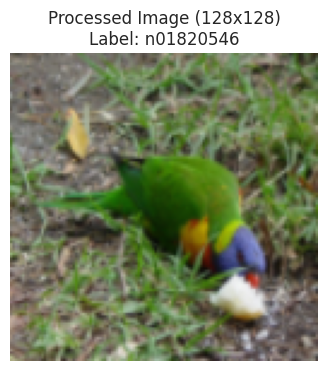

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# 1. Denormalization function
def denormalize(tensor):
    """Reverses the normalization applied during transformations."""
    # Mean and Std used in your transforms
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

    # Undo normalization: (tensor * std) + mean
    tensor = tensor * std + mean
    return torch.clamp(tensor, 0, 1)

# --- Plotting Logic ---

try:
    # 2. Fetch one batch from the training dataloader
    dataiter = iter(train_dataloader)
    images, labels = next(dataiter)

    # 3. Select the first image
    img_tensor = images[0].cpu()  # Get the first tensor and move to CPU
    label_idx = labels[0].item()

    # Use the class names list from your notebook's setup
    class_names = ['n01820546', 'n01833805', 'n01843065', 'n01843383', 'n01855032', 'n01855672', 'n01860187', 'n01872401', 'n01882714', 'n02012849']
    label_name = class_names[label_idx]

    # 4. Denormalize and convert tensor (C, H, W) to NumPy array (H, W, C)
    img_denorm = denormalize(img_tensor)
    img_np = img_denorm.permute(1, 2, 0).numpy()

    # 5. Plot the image
    plt.figure(figsize=(4, 4))
    plt.imshow(img_np)
    plt.title(f"Processed Image ({img_np.shape[0]}x{img_np.shape[1]})\nLabel: {label_name}")
    plt.axis("off")
    plt.show()

except NameError as e:
    print(f"Error: {e}. Please ensure 'train_dataloader' and 'class_names' are defined by running the data setup code first.")
except StopIteration:
    print("Error: Dataloader is empty or already iterated through. Re-run your data setup if needed.")

***

Defining the model mentioned in the co-teaching paper

***

In [ ]:
import math
import torch
import torch.nn as nn
import torch.nn.init as init
import torch.nn.functional as F
import torch.optim as optim

In [ ]:
def call_bn(bn, x):
    return bn(x)

class CNN(nn.Module):
    def __init__(self, input_channel=3, n_outputs=10, dropout_rate=0.25, top_bn=False):
        self.dropout_rate = dropout_rate
        self.top_bn = top_bn
        super(CNN, self).__init__()
        self.c1=nn.Conv2d(input_channel,128,kernel_size=3,stride=1, padding=1)
        self.c2=nn.Conv2d(128,128,kernel_size=3,stride=1, padding=1)
        self.c3=nn.Conv2d(128,128,kernel_size=3,stride=1, padding=1)
        self.c4=nn.Conv2d(128,256,kernel_size=3,stride=1, padding=1)
        self.c5=nn.Conv2d(256,256,kernel_size=3,stride=1, padding=1)
        self.c6=nn.Conv2d(256,256,kernel_size=3,stride=1, padding=1)
        self.c7=nn.Conv2d(256,512,kernel_size=3,stride=1, padding=0)
        self.c8=nn.Conv2d(512,256,kernel_size=3,stride=1, padding=0)
        self.c9=nn.Conv2d(256,128,kernel_size=3,stride=1, padding=0)
        self.l_c1=nn.Linear(128,n_outputs)
        self.bn1=nn.BatchNorm2d(128)
        self.bn2=nn.BatchNorm2d(128)
        self.bn3=nn.BatchNorm2d(128)
        self.bn4=nn.BatchNorm2d(256)
        self.bn5=nn.BatchNorm2d(256)
        self.bn6=nn.BatchNorm2d(256)
        self.bn7=nn.BatchNorm2d(512)
        self.bn8=nn.BatchNorm2d(256)
        self.bn9=nn.BatchNorm2d(128)

    def forward(self, x,):
        h=x
        h=self.c1(h)
        h=F.leaky_relu(call_bn(self.bn1, h), negative_slope=0.01)
        h=self.c2(h)
        h=F.leaky_relu(call_bn(self.bn2, h), negative_slope=0.01)
        h=self.c3(h)
        h=F.leaky_relu(call_bn(self.bn3, h), negative_slope=0.01)
        h=F.max_pool2d(h, kernel_size=2, stride=2)
        h=F.dropout2d(h, p=self.dropout_rate)

        h=self.c4(h)
        h=F.leaky_relu(call_bn(self.bn4, h), negative_slope=0.01)
        h=self.c5(h)
        h=F.leaky_relu(call_bn(self.bn5, h), negative_slope=0.01)
        h=self.c6(h)
        h=F.leaky_relu(call_bn(self.bn6, h), negative_slope=0.01)
        h=F.max_pool2d(h, kernel_size=2, stride=2)
        h=F.dropout2d(h, p=self.dropout_rate)

        h=self.c7(h)
        h=F.leaky_relu(call_bn(self.bn7, h), negative_slope=0.01)
        h=self.c8(h)
        h=F.leaky_relu(call_bn(self.bn8, h), negative_slope=0.01)
        h=self.c9(h)
        h=F.leaky_relu(call_bn(self.bn9, h), negative_slope=0.01)
        h=F.avg_pool2d(h, kernel_size=h.data.shape[2])

        h = h.view(h.size(0), h.size(1))
        logit=self.l_c1(h)
        if self.top_bn:
            logit=call_bn(self.bn_c1, logit)
        return logit

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class CNNFast(nn.Module):
    def __init__(self, input_channel=3, n_outputs=10, dropout_rate=0.25, top_bn=False):
        super().__init__()
        self.dropout_rate = dropout_rate
        self.top_bn = top_bn

        # conv blocks
        self.c1 = nn.Conv2d(input_channel, 128, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(128)
        self.act1 = nn.LeakyReLU(0.01, inplace=True)

        self.c2 = nn.Conv2d(128, 128, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(128)
        self.act2 = nn.LeakyReLU(0.01, inplace=True)

        self.c3 = nn.Conv2d(128, 128, 3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.act3 = nn.LeakyReLU(0.01, inplace=True)

        self.c4 = nn.Conv2d(128, 256, 3, padding=1)
        self.bn4 = nn.BatchNorm2d(256)
        self.act4 = nn.LeakyReLU(0.01, inplace=True)

        self.c5 = nn.Conv2d(256, 256, 3, padding=1)
        self.bn5 = nn.BatchNorm2d(256)
        self.act5 = nn.LeakyReLU(0.01, inplace=True)

        self.c6 = nn.Conv2d(256, 256, 3, padding=1)
        self.bn6 = nn.BatchNorm2d(256)
        self.act6 = nn.LeakyReLU(0.01, inplace=True)

        self.c7 = nn.Conv2d(256, 512, 3, padding=0)
        self.bn7 = nn.BatchNorm2d(512)
        self.act7 = nn.LeakyReLU(0.01, inplace=True)

        self.c8 = nn.Conv2d(512, 256, 3, padding=0)
        self.bn8 = nn.BatchNorm2d(256)
        self.act8 = nn.LeakyReLU(0.01, inplace=True)

        self.c9 = nn.Conv2d(256, 128, 3, padding=0)
        self.bn9 = nn.BatchNorm2d(128)
        self.act9 = nn.LeakyReLU(0.01, inplace=True)

        self.avgpool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Linear(128, n_outputs)

    def forward(self, x):
        x = self.act1(self.bn1(self.c1(x)))
        x = self.act2(self.bn2(self.c2(x)))
        x = self.act3(self.bn3(self.c3(x)))
        x = F.max_pool2d(x, 2, 2)
        x = F.dropout2d(x, p=self.dropout_rate, training=self.training)

        x = self.act4(self.bn4(self.c4(x)))
        x = self.act5(self.bn5(self.c5(x)))
        x = self.act6(self.bn6(self.c6(x)))
        x = F.max_pool2d(x, 2, 2)
        x = F.dropout2d(x, p=self.dropout_rate, training=self.training)

        x = self.act7(self.bn7(self.c7(x)))
        x = self.act8(self.bn8(self.c8(x)))
        x = self.act9(self.bn9(self.c9(x)))

        x = self.avgpool(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class CNN_small(nn.Module):
    def __init__(self, input_channel=3, n_outputs=10, dropout_rate=0.25, top_bn=False):
        super().__init__()
        self.dropout_rate = dropout_rate
        self.top_bn = top_bn

        # conv blocks
        self.c1 = nn.Conv2d(input_channel, 64, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(64)
        self.act1 = nn.LeakyReLU(0.01, inplace=True)

        self.c2 = nn.Conv2d(64, 64, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.act2 = nn.LeakyReLU(0.01, inplace=True)

        self.c3 = nn.Conv2d(64, 32, 3, padding=1)
        self.bn3 = nn.BatchNorm2d(32)
        self.act3 = nn.LeakyReLU(0.01, inplace=True)

        self.c4 = nn.Conv2d(32, 32, 3, padding=1)
        self.bn4 = nn.BatchNorm2d(32)
        self.act4 = nn.LeakyReLU(0.01, inplace=True)

        self.c5 = nn.Conv2d(32, 32, 3, padding=1)
        self.bn5 = nn.BatchNorm2d(32)
        self.act5 = nn.LeakyReLU(0.01, inplace=True)

        # self.c6 = nn.Conv2d(256, 256, 3, padding=1)
        # self.bn6 = nn.BatchNorm2d(256)
        # self.act6 = nn.LeakyReLU(0.01, inplace=True)

        # self.c7 = nn.Conv2d(256, 512, 3, padding=0)
        # self.bn7 = nn.BatchNorm2d(512)
        # self.act7 = nn.LeakyReLU(0.01, inplace=True)

        # self.c8 = nn.Conv2d(512, 256, 3, padding=0)
        # self.bn8 = nn.BatchNorm2d(256)
        # self.act8 = nn.LeakyReLU(0.01, inplace=True)

        # self.c9 = nn.Conv2d(256, 128, 3, padding=0)
        # self.bn9 = nn.BatchNorm2d(128)
        # self.act9 = nn.LeakyReLU(0.01, inplace=True)

        self.avgpool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Linear(32, n_outputs)

    def forward(self, x):
        x = self.act1(self.bn1(self.c1(x)))
        x = self.act2(self.bn2(self.c2(x)))
        x = self.act3(self.bn3(self.c3(x)))
        x = F.max_pool2d(x, 2, 2)
        x = F.dropout2d(x, p=self.dropout_rate, training=self.training)

        x = self.act4(self.bn4(self.c4(x)))
        x = self.act5(self.bn5(self.c5(x)))
        # x = self.act6(self.bn6(self.c6(x)))
        # x = F.max_pool2d(x, 2, 2)
        # x = F.dropout2d(x, p=self.dropout_rate, training=self.training)

        # x = self.act7(self.bn7(self.c7(x)))
        # x = self.act8(self.bn8(self.c8(x)))
        # x = self.act9(self.bn9(self.c9(x)))

        x = self.avgpool(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x


In [ ]:
# co-teaching loss

import torch
import torch.nn.functional as F

# ignoring noise_or_not for now
def loss_coteaching_safe(y1, y2, t, forget_rate, ind, noise_or_not=None):
    """
    y1, y2: torch tensors (batch_size, num_classes) on device
    t: torch.LongTensor (batch_size,)
    forget_rate: float between 0 and 1
    ind: 1D tensor or numpy array of global indices for this batch (length batch_size)
    noise_or_not: 1D array/tensor indicating clean=1/noisy=0 indexed by global idx
    """
    device = y1.device
    # per-sample losses
    loss1 = F.cross_entropy(y1, t, reduction='none')
    loss2 = F.cross_entropy(y2, t, reduction='none')

    # argsort ascending (small to large)
    ind1_sorted = torch.argsort(loss1)
    ind2_sorted = torch.argsort(loss2)

    remember_rate = 1.0 - float(forget_rate)
    num_remember = int(remember_rate * loss1.shape[0])
    if num_remember <= 0:
        # Nothing to remember: return zero losses and zero purity
        zero = torch.tensor(0.0, device=device)
        return zero, zero, 0.0, 0.0

    ind1_update = ind1_sorted[:num_remember]
    ind2_update = ind2_sorted[:num_remember]

    # compute pure ratios (convert to numpy or torch consistently)
    # ensure ind is a numpy array or torch tensor on cpu for indexing noise_or_not if noise_or_not is numpy
    # if isinstance(noise_or_not, torch.Tensor):
    #     # assume noise_or_not is global tensor on same device or cpu
    #     # ind may be torch tensor with global indices
    #     nr = noise_or_not
    #     idx1 = ind[ind1_update].to(nr.device)
    #     idx2 = ind[ind2_update].to(nr.device)
    #     pure_ratio_1 = float(nr[idx1].sum().item()) / num_remember
    #     pure_ratio_2 = float(nr[idx2].sum().item()) / num_remember
    # else:
    #     # noise_or_not is numpy array
    #     ind_np = ind.cpu().numpy() if isinstance(ind, torch.Tensor) else ind
    #     sel1 = ind_np[ind1_update.cpu().numpy()]
    #     sel2 = ind_np[ind2_update.cpu().numpy()]
    #     pure_ratio_1 = float(noise_or_not[sel1].sum()) / num_remember
    #     pure_ratio_2 = float(noise_or_not[sel2].sum()) / num_remember

    # cross-update losses
    loss1_update = F.cross_entropy(y1[ind2_update], t[ind2_update], reduction='mean')
    loss2_update = F.cross_entropy(y2[ind1_update], t[ind1_update], reduction='mean')

    return loss1_update, loss2_update, 0, 0 #pure_ratio_1, pure_ratio_2


In [ ]:
import torch
import torch.nn.functional as F

def loss_coteaching_safe_fast(y1, y2, t, forget_rate, ind=None, noise_or_not=None):
    """
    Faster co-teaching loss while keeping the same behavior.
    """
    device = y1.device
    batch_size = t.size(0)

    # 1. Compute per-sample losses
    loss1 = F.cross_entropy(y1, t, reduction='none')
    loss2 = F.cross_entropy(y2, t, reduction='none')

    # 2. Determine how many samples to remember
    remember_rate = 1.0 - float(forget_rate)
    num_remember = max(int(remember_rate * batch_size), 1)

    # 3. Select indices of smallest losses without full sort
    _, ind1_small = torch.topk(loss1, k=num_remember, largest=False)
    _, ind2_small = torch.topk(loss2, k=num_remember, largest=False)

    # 4. Cross-update: compute mean of selected samples
    loss1_update = F.cross_entropy(y1[ind2_small], t[ind2_small], reduction='mean')
    loss2_update = F.cross_entropy(y2[ind1_small], t[ind1_small], reduction='mean')

    return loss1_update, loss2_update, 0, 0


In [ ]:
def evaluate_test_set(test_dataloader, model):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_dataloader:
            images = images.to(device)
            labels = labels.to(device)
            logits = model(images)
            preds = torch.argmax(logits, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    model.train()  # restore train mode as it does not happen automatically
    return correct / total if total > 0 else 0.0


In [ ]:
# model training loop
def model_training_loop(train_dataloader,
                        test_dataloader,
                        noise_rate):
    torch.manual_seed(1)
    save_dir = "/content/drive/MyDrive/project_CNN_noisy_label/Dataset 1/Noisy_label_result"

    learning_rate = 0.01
    NUM_EPOCHS = 30
    train_accuracy_1_dict = {}
    train_loss_1_dict = {}
    train_accuracy_2_dict = {}
    train_loss_2_dict = {}

    test_accuracy_1_dict = {}
    test_accuracy_2_dict = {}


    # get the rate scheduler which decides how many samples to remember and to forget
    # the code below does the following
    # gradually increase the fraction of noisy samples for the first N epochs and then keep it constant
    # num_gradual: how many epochs for linear drop rate, can be 5, 10, 15. This parameter is equal to Tk for R(T) in Co-teaching paper.

    num_gradual = 10 # keeping it 2 because we are executing for only 10 epochs
    exponent = 1
    rate_schedule = np.ones(NUM_EPOCHS)*noise_rate
    rate_schedule[:num_gradual] = np.linspace(0, noise_rate**exponent, num_gradual)

    # init CNN_1
    # init CNN_2
    # cnn_1 = CNNFast().train()
    cnn_1 = CNN_small().train()
    cnn_1.to(device)
    optimizer_1 = torch.optim.Adam(cnn_1.parameters(), lr=learning_rate)

    # cnn_2 = CNNFast().train()
    cnn_2 = CNN_small().train()
    cnn_2.to(device)
    optimizer_2 = torch.optim.Adam(cnn_2.parameters(), lr=learning_rate)

    # run it for certain number of epochs
    for epoch in range(NUM_EPOCHS):
        # for accuracy calculation
        train_correct_1 = 0
        train_correct_2 = 0
        train_total_1 = 0

        for batch_idx, (features, labels) in enumerate(train_dataloader):

            features = features.to(device)
            labels = labels.to(device)


            # get predictions
            # with torch.no_grad():
            model_1_predictions_logits = cnn_1(features)
            model_2_predictions_logits = cnn_2(features)

            model_1_prediction = torch.argmax(model_1_predictions_logits, dim=1)
            model_2_prediction = torch.argmax(model_2_predictions_logits, dim=1)
            # print(model_1_prediction, model_2_prediction)

            train_correct_1 += (model_1_prediction == labels).sum().item()
            train_correct_2 += (model_2_prediction == labels).sum().item()

            train_total_1 += labels.size(0)

            # get the loss from CNN1
            # get the loss from CNN2
            loss_1, loss_2, _, _ = loss_coteaching_safe(y1=model_1_predictions_logits,
                                                        y2=model_2_predictions_logits,
                                                        t=labels,
                                                        forget_rate=rate_schedule[epoch], # keeping a fixed forget rate for now
                                                        ind=None, # excluding indices for now
                                                        noise_or_not=None
                                                        )
            # pass the losses to cross update co-teaching function
            optimizer_1.zero_grad()
            loss_1.backward()
            optimizer_1.step()

            optimizer_2.zero_grad()
            loss_2.backward()
            optimizer_2.step()



            # based on the losses do backward pass
            # update the optimizers
            if batch_idx % 100 == 0:
                print(f"Epoch: {epoch+1:03d}/{NUM_EPOCHS:03d}"
                    f" | Batch {batch_idx:03d}/{len(train_dataloader):03d}"
                    f" | Train Loss for CNN 1: {loss_1:.4f}"
                    f" | Train Loss for CNN 2: {loss_2:.4f}")

        train_loss_1_dict[epoch] = loss_1
        train_loss_2_dict[epoch] = loss_2

        # get the accuracy on train set
        train_accuracy_1 = float(train_correct_1) / float(train_total_1)
        train_accuracy_2 = float(train_correct_2) / float(train_total_1)
        train_accuracy_1_dict[epoch] = train_accuracy_1
        train_accuracy_2_dict[epoch] = train_accuracy_2

        # test set evaluation
        if test_dataloader is not None:
            test_accuracy_1 = evaluate_test_set(test_dataloader, cnn_1)
            test_accuracy_2 = evaluate_test_set(test_dataloader, cnn_2)
            test_accuracy_1_dict[epoch] = test_accuracy_1
            test_accuracy_2_dict[epoch] = test_accuracy_2

            # if epoch % 10 == 0:
            print(f"Epoch: {epoch+1:03d}/{NUM_EPOCHS:03d}"
                f" | TestAcc1: {test_accuracy_1:.4f}, TestAcc2: {test_accuracy_2:.4f}")


        torch.save({"epoch": epoch,
              "model_state_dict": cnn_1.state_dict(),
              "optimizer_state_dict": optimizer_1.state_dict(),
              "train_loss_1": train_loss_1_dict[epoch],
              "train_loss_2": train_loss_2_dict[epoch],
              "train_accuracy_1": train_accuracy_1_dict[epoch],
              "train_accuracy_2": train_accuracy_2_dict[epoch],
              "test_accuracy_1": test_accuracy_1_dict[epoch],
              "test_accuracy_2": test_accuracy_2_dict[epoch],
              },
        f'{save_dir}/co_teaching_{noise_rate}_{epoch}.pth')




In [ ]:
model_training_loop(train_dataloader=train_dataloader,
                    test_dataloader=test_dataloader,
                    noise_rate=NOISE_RATE)

Epoch: 001/030 | Batch 000/097 | Train Loss for CNN 1: 2.3279 | Train Loss for CNN 2: 2.3440
Epoch: 001/030 | TestAcc1: 0.3580, TestAcc2: 0.3620
Epoch: 002/030 | Batch 000/097 | Train Loss for CNN 1: 1.6445 | Train Loss for CNN 2: 1.6902
Epoch: 002/030 | TestAcc1: 0.4300, TestAcc2: 0.4060
Epoch: 003/030 | Batch 000/097 | Train Loss for CNN 1: 1.5045 | Train Loss for CNN 2: 1.4879
Epoch: 003/030 | TestAcc1: 0.4480, TestAcc2: 0.4520
Epoch: 004/030 | Batch 000/097 | Train Loss for CNN 1: 1.3259 | Train Loss for CNN 2: 1.2497
Epoch: 004/030 | TestAcc1: 0.4640, TestAcc2: 0.4520
Epoch: 005/030 | Batch 000/097 | Train Loss for CNN 1: 1.1144 | Train Loss for CNN 2: 1.1793
Epoch: 005/030 | TestAcc1: 0.4320, TestAcc2: 0.4700
Epoch: 006/030 | Batch 000/097 | Train Loss for CNN 1: 0.8936 | Train Loss for CNN 2: 0.9033
Epoch: 006/030 | TestAcc1: 0.4760, TestAcc2: 0.4520
Epoch: 007/030 | Batch 000/097 | Train Loss for CNN 1: 0.9613 | Train Loss for CNN 2: 0.9247
Epoch: 007/030 | TestAcc1: 0.4560, Te

In [8]:
import torch

# Make list of values
train_loss_1= []
train_loss_2= []
train_accuracy_1=[]
train_accuracy_2=[]
test_accuracy_1=[]
test_accuracy_2=[]
noise_rate = 0.2

for i in range(0,30):

  file_path = f"/content/drive/MyDrive/project_CNN_noisy_label/Dataset 1/Noisy_label_result/co_teaching_{noise_rate}_{i}.pth"

  checkpoint = torch.load(file_path, map_location="cpu")

  def to_float(value):
        if isinstance(value, torch.Tensor):
            return value.item() # Converts tensor to standard Python number (float or int)
        return float(value)    # Converts standard number to float

    # Convert each item to float and append
  train_loss_1.append(to_float(checkpoint['train_loss_1']))
  train_loss_2.append(to_float(checkpoint['train_loss_2']))
  train_accuracy_1.append(to_float(checkpoint['train_accuracy_1']))
  train_accuracy_2.append(to_float(checkpoint['train_accuracy_2']))
  test_accuracy_1.append(to_float(checkpoint['test_accuracy_1']))
  test_accuracy_2.append(to_float(checkpoint['test_accuracy_2']))

# Complete the print statements to display all collected metrics
print('For Noise rate:', noise_rate)
print('\n--- MODEL 1 METRICS ---')
print('Train loss first model:', train_loss_1)
print('Train accuracy first model:', train_accuracy_1)
print('Test accuracy first model:', test_accuracy_1)

print('\n--- MODEL 2 METRICS ---')
print('Train loss second model:',  train_loss_2 )
print('Train accuracy second model:', train_accuracy_2 )
print('Test accuracy second model:', test_accuracy_2 )

For Noise rate: 0.2

--- MODEL 1 METRICS ---
Train loss first model: [2.0133960247039795, 1.5829079151153564, 1.464335560798645, 1.2209187746047974, 1.275254726409912, 1.1733914613723755, 1.640613079071045, 1.339188814163208, 0.8698680400848389, 1.0929137468338013, 0.8979310393333435, 0.6593902111053467, 0.7496469020843506, 1.165931224822998, 1.1117489337921143, 0.9639158248901367, 1.0730769634246826, 0.727859377861023, 1.5191203355789185, 0.5646383166313171, 1.1690034866333008, 1.1791998147964478, 0.7455136775970459, 0.8514368534088135, 1.0982071161270142, 0.5876025557518005, 0.48109880089759827, 0.5924225449562073, 0.6031398177146912, 0.5538703799247742]
Train accuracy first model: [0.2824501701507049, 0.37919299951385516, 0.40106951871657753, 0.42675417274347754, 0.436558094312105, 0.44231080862096905, 0.45503159941662613, 0.4656457624372063, 0.47763733592610597, 0.4877653540755145, 0.4913304164641063, 0.5012963863231243, 0.5093988008426511, 0.5155566358774915, 0.5257656781720953, 0

In [9]:
import torch

# Make list of values
train_loss_1= []
train_loss_2= []
train_accuracy_1=[]
train_accuracy_2=[]
test_accuracy_1=[]
test_accuracy_2=[]
noise_rate = 0.4

for i in range(0,30):
  file_path = f"/content/drive/MyDrive/project_CNN_noisy_label/Dataset 1/Noisy_label_result/co_teaching_{noise_rate}_{i}.pth"

  checkpoint = torch.load(file_path, map_location="cpu")

  def to_float(value):
        if isinstance(value, torch.Tensor):
            return value.item() # Converts tensor to standard Python number (float or int)
        return float(value)    # Converts standard number to float

    # Convert each item to float and append
  train_loss_1.append(to_float(checkpoint['train_loss_1']))
  train_loss_2.append(to_float(checkpoint['train_loss_2']))
  train_accuracy_1.append(to_float(checkpoint['train_accuracy_1']))
  train_accuracy_2.append(to_float(checkpoint['train_accuracy_2']))
  test_accuracy_1.append(to_float(checkpoint['test_accuracy_1']))
  test_accuracy_2.append(to_float(checkpoint['test_accuracy_2']))

# Complete the print statements to display all collected metrics
print('For Noise rate:', noise_rate)
print('\n--- MODEL 1 METRICS ---')
print('Train loss first model:', train_loss_1)
print('Train accuracy first model:', train_accuracy_1)
print('Test accuracy first model:', test_accuracy_1)

print('\n--- MODEL 2 METRICS ---')
print('Train loss second model:',  train_loss_2 )
print('Train accuracy second model:', train_accuracy_2 )
print('Test accuracy second model:', test_accuracy_2 )

For Noise rate: 0.4

--- MODEL 1 METRICS ---
Train loss first model: [2.0133960247039795, 1.6146458387374878, 1.4558227062225342, 1.037255048751831, 1.109010934829712, 0.78734290599823, 1.4197760820388794, 1.101525068283081, 0.46531832218170166, 0.6779000759124756, 0.532537579536438, 0.20098569989204407, 0.3423409163951874, 0.7377355098724365, 0.6077242493629456, 0.5029786825180054, 0.6772977113723755, 0.43494299054145813, 1.0371143817901611, 0.4169747233390808, 0.3613755702972412, 0.8837733268737793, 0.341571569442749, 0.5857635736465454, 0.5040831565856934, 0.3033149838447571, 0.28138983249664307, 0.36223500967025757, 0.26015254855155945, 0.2385254204273224]
Train accuracy first model: [0.2824501701507049, 0.3783017339167072, 0.40560687084751257, 0.4304812834224599, 0.43566682871495704, 0.4402041808458921, 0.44563279857397503, 0.45883973424080376, 0.4625668449197861, 0.46904877653540755, 0.47050721114892236, 0.47877167395883974, 0.4875222816399287, 0.4824987846378221, 0.4856587263004

In [11]:
import torch

# Make list of values
train_loss_1= []
train_loss_2= []
train_accuracy_1=[]
train_accuracy_2=[]
test_accuracy_1=[]
test_accuracy_2=[]
noise_rate = 0.6

for i in range(0,30):

  file_path = f"/content/drive/MyDrive/project_CNN_noisy_label/Dataset 1/Noisy_label_result/co_teaching_{noise_rate}_{i}.pth"

  checkpoint = torch.load(file_path, map_location="cpu")

  def to_float(value):
        if isinstance(value, torch.Tensor):
            return value.item() # Converts tensor to standard Python number (float or int)
        return float(value)    # Converts standard number to float

    # Convert each item to float and append
  train_loss_1.append(to_float(checkpoint['train_loss_1']))
  train_loss_2.append(to_float(checkpoint['train_loss_2']))
  train_accuracy_1.append(to_float(checkpoint['train_accuracy_1']))
  train_accuracy_2.append(to_float(checkpoint['train_accuracy_2']))
  test_accuracy_1.append(to_float(checkpoint['test_accuracy_1']))
  test_accuracy_2.append(to_float(checkpoint['test_accuracy_2']))

# Complete the print statements to display all collected metrics
print('For Noise rate:', noise_rate)
print('\n--- MODEL 1 METRICS ---')
print('Train loss first model:', train_loss_1)
print('Train accuracy first model:', train_accuracy_1)
print('Test accuracy first model:', test_accuracy_1)

print('\n--- MODEL 2 METRICS ---')
print('Train loss second model:',  train_loss_2 )
print('Train accuracy second model:', train_accuracy_2 )
print('Test accuracy second model:', test_accuracy_2 )

For Noise rate: 0.6

--- MODEL 1 METRICS ---
Train loss first model: [2.0133960247039795, 1.4372613430023193, 1.3185951709747314, 0.9613736867904663, 0.8653979301452637, 0.5423762798309326, 0.8968762755393982, 0.7695507407188416, 0.09753301739692688, 0.828088104724884, 0.0746493861079216, 0.024456137791275978, 0.42007526755332947, 0.4574717581272125, 0.07374829053878784, 0.13343438506126404, 0.22678782045841217, 0.14560522139072418, 0.3239933252334595, 0.04913333058357239, 0.22669757902622223, 0.5705059170722961, 0.2102598398923874, 0.2715489864349365, 0.673607349395752, 0.09153285622596741, 0.07700300961732864, 0.030871406197547913, 0.05152582377195358, 0.05611081421375275]
Train accuracy first model: [0.2824501701507049, 0.3780586614811214, 0.4035812672176309, 0.43364122508507535, 0.4408523740074542, 0.4347755631178091, 0.4483065953654189, 0.44506562955760814, 0.45041322314049587, 0.43283098363312267, 0.43218279047156055, 0.4316966456003889, 0.4358288770053476, 0.4419056878949927, 0.